# Dataset 8: Chest X-ray Density and Tail Risk

Mean radiodensity can miss clinically important tail behavior and heterogeneous outcomes.

Source and citation:
- Yang et al. (2020) interpretation style; workshop includes partial table plus tail-risk framing.

This notebook follows the common Workshop 3 structure:
1. Build dataset
2. Classical analysis (mean, median, interval analysis, error bars)
3. Machine Gnostics analysis
4. Linear and polynomial regression comparison
5. Final interpretation for small-data settings


## Step 0: Setup
Install dependencies if needed:
- `pip install numpy pandas matplotlib seaborn scipy scikit-learn machinegnostics`


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')

MG_AVAILABLE = True
MG_IMPORT_ERROR = None

try:
    from machinegnostics.magcal import ELDF, EGDF, IntervalAnalysis
    from machinegnostics.models import LinearRegressor, PolynomialRegressor
    from machinegnostics.metrics import (
        mean as mg_mean,
        median as mg_median,
        correlation as mg_correlation,
        root_mean_squared_error,
        robr2,
    )
except Exception as exc:
    MG_AVAILABLE = False
    MG_IMPORT_ERROR = str(exc)
    print('Machine Gnostics import unavailable. Notebook will run with classical fallbacks.')
    print('Import error:', MG_IMPORT_ERROR)


In [2]:
def classical_summary(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mean_y = float(np.mean(y))
    median_y = float(np.median(y))
    std_y = float(np.std(y, ddof=1)) if len(y) > 1 else 0.0
    sem = std_y / np.sqrt(len(y)) if len(y) > 1 else 0.0
    ci_margin = 1.96 * sem

    corr = float(np.corrcoef(x, y)[0, 1]) if len(np.unique(x)) > 1 and len(np.unique(y)) > 1 else np.nan

    lin = LinearRegression().fit(x.reshape(-1, 1), y)
    y_lin = lin.predict(x.reshape(-1, 1))

    poly = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
    poly.fit(x.reshape(-1, 1), y)
    y_poly = poly.predict(x.reshape(-1, 1))

    return {
        'mean_y': mean_y,
        'median_y': median_y,
        'std_y': std_y,
        'ci_low': mean_y - ci_margin,
        'ci_high': mean_y + ci_margin,
        'corr_xy': corr,
        'lin_model': lin,
        'lin_pred': y_lin,
        'lin_r2': float(r2_score(y, y_lin)),
        'lin_rmse': float(np.sqrt(mean_squared_error(y, y_lin))),
        'poly_model': poly,
        'poly_pred': y_poly,
        'poly_r2': float(r2_score(y, y_poly)),
        'poly_rmse': float(np.sqrt(mean_squared_error(y, y_poly))),
    }


def mg_summary(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if not MG_AVAILABLE:
        return {
            'available': False,
            'error': MG_IMPORT_ERROR,
            'mean_y': np.nan,
            'median_y': np.nan,
            'corr_xy': np.nan,
            'typical_low': np.nan,
            'typical_high': np.nan,
            'tolerance_low': np.nan,
            'tolerance_high': np.nan,
            'lin_r2': np.nan,
            'lin_rmse': np.nan,
            'poly_r2': np.nan,
            'poly_rmse': np.nan,
            'lin_pred': np.full_like(y, np.nan, dtype=float),
            'poly_pred': np.full_like(y, np.nan, dtype=float),
        }

    out = {
        'available': True,
        'error': None,
    }

    try:
        out['mean_y'] = float(mg_mean(y))
    except Exception:
        out['mean_y'] = float(np.mean(y))

    try:
        out['median_y'] = float(mg_median(y))
    except Exception:
        out['median_y'] = float(np.median(y))

    try:
        out['corr_xy'] = float(mg_correlation(x, y))
    except Exception:
        out['corr_xy'] = float(np.corrcoef(x, y)[0, 1]) if len(np.unique(x)) > 1 and len(np.unique(y)) > 1 else np.nan

    try:
        ia = IntervalAnalysis(n_points=100, flush=False, verbose=False)
        ia.fit(y)
        ia_res = ia.results()
        out['typical_low'] = float(ia_res.get('ZL', np.nan))
        out['typical_high'] = float(ia_res.get('ZU', np.nan))
        out['tolerance_low'] = float(ia_res.get('Z0L', np.nan))
        out['tolerance_high'] = float(ia_res.get('Z0U', np.nan))
    except Exception:
        out['typical_low'] = np.nan
        out['typical_high'] = np.nan
        out['tolerance_low'] = np.nan
        out['tolerance_high'] = np.nan

    # Machine Gnostics linear regression
    try:
        mg_lin = LinearRegressor(max_iter=300, early_stopping=True, tolerance=1e-6, mg_loss='hi', history=False, verbose=False)
        mg_lin.fit(x, y)
        y_mg_lin = np.asarray(mg_lin.predict(x), dtype=float)
        out['lin_pred'] = y_mg_lin
        try:
            out['lin_r2'] = float(robr2(y, y_mg_lin, w=getattr(mg_lin, 'weights', None)))
        except Exception:
            out['lin_r2'] = float(r2_score(y, y_mg_lin))
        try:
            out['lin_rmse'] = float(root_mean_squared_error(y, y_mg_lin))
        except Exception:
            out['lin_rmse'] = float(np.sqrt(mean_squared_error(y, y_mg_lin)))
    except Exception:
        lin = LinearRegression().fit(x.reshape(-1, 1), y)
        y_mg_lin = lin.predict(x.reshape(-1, 1))
        out['lin_pred'] = y_mg_lin
        out['lin_r2'] = float(r2_score(y, y_mg_lin))
        out['lin_rmse'] = float(np.sqrt(mean_squared_error(y, y_mg_lin)))

    # Machine Gnostics polynomial regression
    try:
        mg_poly = PolynomialRegressor(degree=2, max_iter=300, early_stopping=True, tolerance=1e-6, verbose=False)
        mg_poly.fit(x, y)
        y_mg_poly = np.asarray(mg_poly.predict(x), dtype=float)
        out['poly_pred'] = y_mg_poly
        try:
            out['poly_r2'] = float(robr2(y, y_mg_poly, w=getattr(mg_poly, 'weights', None)))
        except Exception:
            out['poly_r2'] = float(r2_score(y, y_mg_poly))
        try:
            out['poly_rmse'] = float(root_mean_squared_error(y, y_mg_poly))
        except Exception:
            out['poly_rmse'] = float(np.sqrt(mean_squared_error(y, y_mg_poly)))
    except Exception:
        poly = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
        poly.fit(x.reshape(-1, 1), y)
        y_mg_poly = poly.predict(x.reshape(-1, 1))
        out['poly_pred'] = y_mg_poly
        out['poly_r2'] = float(r2_score(y, y_mg_poly))
        out['poly_rmse'] = float(np.sqrt(mean_squared_error(y, y_mg_poly)))

    return out


def eldf_curves(values):
    vals = np.asarray(values, dtype=float)
    vals_sorted = np.sort(vals)
    empirical = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)

    x_curve = vals_sorted
    cdf_curve = empirical
    pdf_curve = gaussian_kde(vals_sorted)(vals_sorted)

    if MG_AVAILABLE:
        try:
            eldf = ELDF(flush=False)
            eldf.fit(vals_sorted)
            maybe_x = getattr(eldf, 'di_points', None)
            maybe_cdf = getattr(eldf, 'eldf_points', None)
            maybe_pdf = getattr(eldf, 'pdf_points', None)

            if maybe_x is not None and maybe_cdf is not None and maybe_pdf is not None:
                x_curve = np.asarray(maybe_x, dtype=float).reshape(-1)
                cdf_curve = np.asarray(maybe_cdf, dtype=float).reshape(-1)
                pdf_curve = np.asarray(maybe_pdf, dtype=float).reshape(-1)
                order = np.argsort(x_curve)
                x_curve = x_curve[order]
                cdf_curve = cdf_curve[order]
                pdf_curve = pdf_curve[order]
        except Exception:
            pass

    return vals_sorted, empirical, x_curve, cdf_curve, pdf_curve


## Step 1: Create Dataset
This cell recreates the dataset from the Workshop 3 real-datasets reference.


In [3]:
records = [
    {'patient':1,'density_hu':-450,'o2_sat':94,'outcome':'Discharged'},
    {'patient':2,'density_hu':-480,'o2_sat':95,'outcome':'Discharged'},
    {'patient':3,'density_hu':-420,'o2_sat':93,'outcome':'Discharged'},
    {'patient':4,'density_hu':-410,'o2_sat':92,'outcome':'Discharged'},
    {'patient':5,'density_hu':-390,'o2_sat':91,'outcome':'Discharged'},
    {'patient':6,'density_hu':-510,'o2_sat':96,'outcome':'Discharged'},
    {'patient':7,'density_hu':-540,'o2_sat':97,'outcome':'Discharged'},
    {'patient':8,'density_hu':-580,'o2_sat':96,'outcome':'Deceased'},
    {'patient':9,'density_hu':-560,'o2_sat':95,'outcome':'Discharged'},
    {'patient':10,'density_hu':-630,'o2_sat':92,'outcome':'Deceased'},
    {'patient':11,'density_hu':-420,'o2_sat':88,'outcome':'ICU'},
    {'patient':12,'density_hu':-650,'o2_sat':89,'outcome':'ICU'},
    {'patient':13,'density_hu':-470,'o2_sat':94,'outcome':'Discharged'},
    {'patient':14,'density_hu':-505,'o2_sat':93,'outcome':'Discharged'},
    {'patient':15,'density_hu':-455,'o2_sat':95,'outcome':'Discharged'},
    {'patient':16,'density_hu':-600,'o2_sat':90,'outcome':'ICU'},
    {'patient':17,'density_hu':-615,'o2_sat':91,'outcome':'ICU'},
    {'patient':18,'density_hu':-575,'o2_sat':92,'outcome':'Discharged'},
    {'patient':19,'density_hu':-440,'o2_sat':96,'outcome':'Discharged'},
    {'patient':20,'density_hu':-430,'o2_sat':95,'outcome':'Discharged'},
    {'patient':21,'density_hu':-525,'o2_sat':94,'outcome':'Discharged'},
    {'patient':22,'density_hu':-642,'o2_sat':89,'outcome':'Deceased'},
    {'patient':23,'density_hu':-598,'o2_sat':90,'outcome':'ICU'},
    {'patient':24,'density_hu':-462,'o2_sat':95,'outcome':'Discharged'},
]

df = pd.DataFrame(records)


x_col = 'density_hu'
y_col = 'o2_sat'

df.head(), df.shape


(   patient  density_hu  o2_sat     outcome
 0        1        -450      94  Discharged
 1        2        -480      95  Discharged
 2        3        -420      93  Discharged
 3        4        -410      92  Discharged
 4        5        -390      91  Discharged,
 (24, 4))

## Step 2: Classical Baseline (Mean, Median, CI, Linear and Polynomial Regression)
We compute the classical descriptive metrics and two regression baselines.


In [4]:
x = df[x_col].to_numpy(dtype=float)
y = df[y_col].to_numpy(dtype=float)

cls = classical_summary(x, y)

summary_classical = pd.DataFrame(
    {
        'metric': ['mean(y)', 'median(y)', 'std(y)', '95% CI low', '95% CI high', 'corr(x,y)', 'linear R2', 'linear RMSE', 'poly(2) R2', 'poly(2) RMSE'],
        'value': [
            cls['mean_y'], cls['median_y'], cls['std_y'], cls['ci_low'], cls['ci_high'],
            cls['corr_xy'], cls['lin_r2'], cls['lin_rmse'], cls['poly_r2'], cls['poly_rmse']
        ],
    }
)
summary_classical


,metric,value
0,mean(y),93.000000
1,median(y),93.500000
2,std(y),2.570738
3,95% CI low,91.971490
4,95% CI high,94.028510
5,"corr(x,y)",0.313931
6,linear R2,0.098553
7,linear RMSE,2.389386
8,poly(2) R2,0.551017
9,poly(2) RMSE,1.686285


## Step 3: Classical Error Bars and Distribution Plotting
This figure combines error bars and distributions to show uncertainty and central tendency.


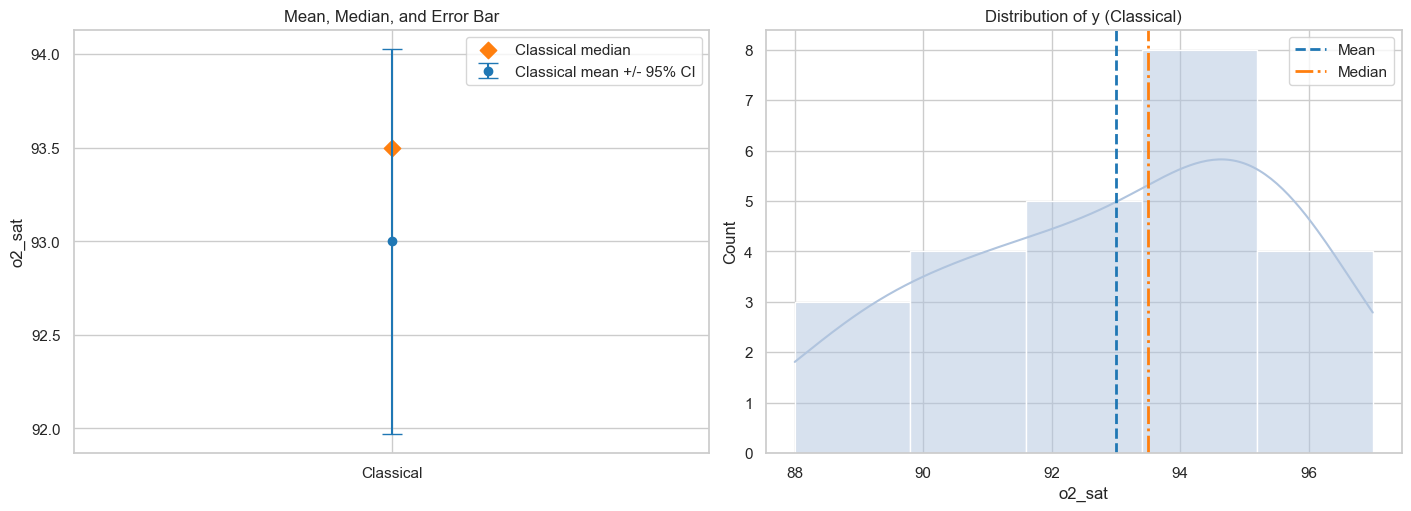

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Panel A: mean with 95% CI + median marker
ax = axes[0]
ax.errorbar(
    x=[0],
    y=[cls['mean_y']],
    yerr=[[cls['mean_y'] - cls['ci_low']], [cls['ci_high'] - cls['mean_y']]],
    fmt='o',
    capsize=7,
    color='tab:blue',
    label='Classical mean +/- 95% CI',
)
ax.scatter([0], [cls['median_y']], marker='D', color='tab:orange', s=70, label='Classical median')
ax.set_xticks([0])
ax.set_xticklabels(['Classical'])
ax.set_ylabel(y_col)
ax.set_title('Mean, Median, and Error Bar')
ax.legend(loc='best')

# Panel B: histogram + KDE + vertical mean/median
ax = axes[1]
sns.histplot(y, bins=min(12, max(5, int(np.sqrt(len(y))))), kde=True, ax=ax, color='lightsteelblue', edgecolor='white')
ax.axvline(cls['mean_y'], color='tab:blue', linestyle='--', linewidth=2, label='Mean')
ax.axvline(cls['median_y'], color='tab:orange', linestyle='-.', linewidth=2, label='Median')
ax.set_title('Distribution of y (Classical)')
ax.set_xlabel(y_col)
ax.legend(loc='best')

plt.show()


## Step 4: Machine Gnostics Metrics and Interval Analysis
We compute Machine Gnostics mean, median, correlation, and interval bounds.


In [6]:
mg = mg_summary(x, y)

summary_mg = pd.DataFrame(
    {
        'metric': ['mg_mean(y)', 'mg_median(y)', 'mg_corr(x,y)', 'typical_low', 'typical_high', 'tolerance_low', 'tolerance_high', 'mg_linear_R2', 'mg_linear_RMSE', 'mg_poly_R2', 'mg_poly_RMSE'],
        'value': [
            mg['mean_y'], mg['median_y'], mg['corr_xy'],
            mg['typical_low'], mg['typical_high'], mg['tolerance_low'], mg['tolerance_high'],
            mg['lin_r2'], mg['lin_rmse'], mg['poly_r2'], mg['poly_rmse']
        ],
    }
)
summary_mg


,metric,value
0,mg_mean(y),94.030000
1,mg_median(y),93.274000
2,"mg_corr(x,y)",0.985022
3,typical_low,91.875308
4,typical_high,95.788166
5,tolerance_low,93.698406
6,tolerance_high,94.220322
7,mg_linear_R2,0.996075
8,mg_linear_RMSE,1.421238
9,mg_poly_R2,0.999080


## Step 5: ELDF/Empirical CDF/PDF Comparison
This panel compares empirical CDF and KDE PDF against ELDF-derived curves when available.


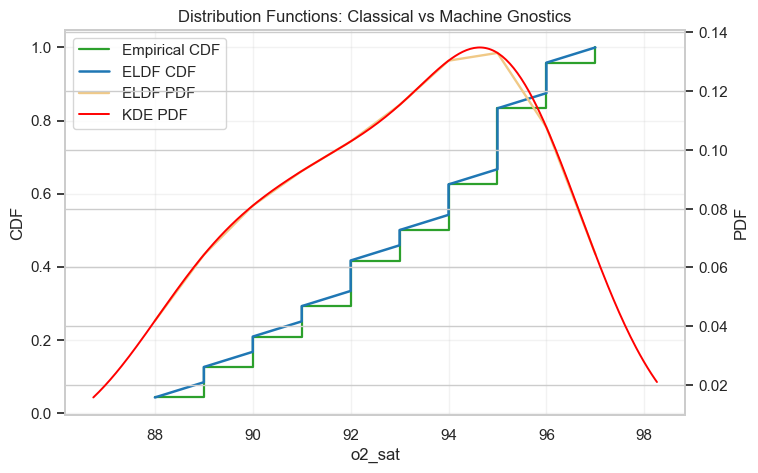

In [7]:
vals_sorted, empirical, x_curve, cdf_curve, pdf_curve = eldf_curves(y)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.step(vals_sorted, empirical, where='post', color='tab:green', linewidth=1.6, label='Empirical CDF')
ax1.plot(x_curve, cdf_curve, color='tab:blue', linewidth=1.8, label='ELDF CDF')
ax1.axvline(cls['mean_y'], color='tab:blue', linestyle='--', linewidth=1.5, label='Classical mean')
if np.isfinite(mg['mean_y']):
    ax1.axvline(mg['mean_y'], color='tab:red', linestyle='-.', linewidth=1.5, label='MG mean')

x_dense = np.linspace(vals_sorted.min() - 0.5 * np.std(vals_sorted), vals_sorted.max() + 0.5 * np.std(vals_sorted), 300)
kde = gaussian_kde(vals_sorted)
ax2.plot(x_curve, pdf_curve, color='#f0c987', linewidth=1.7, label='ELDF PDF')
ax2.plot(x_dense, kde(x_dense), color='red', linewidth=1.4, label='KDE PDF')

ax1.set_xlabel(y_col)
ax1.set_ylabel('CDF')
ax2.set_ylabel('PDF')
ax1.set_title('Distribution Functions: Classical vs Machine Gnostics')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best')
ax1.grid(alpha=0.25)
plt.show()


## Step 6: Linear and Polynomial Regression Comparison
Both classical and Machine Gnostics fits are shown on the same scatter plot.


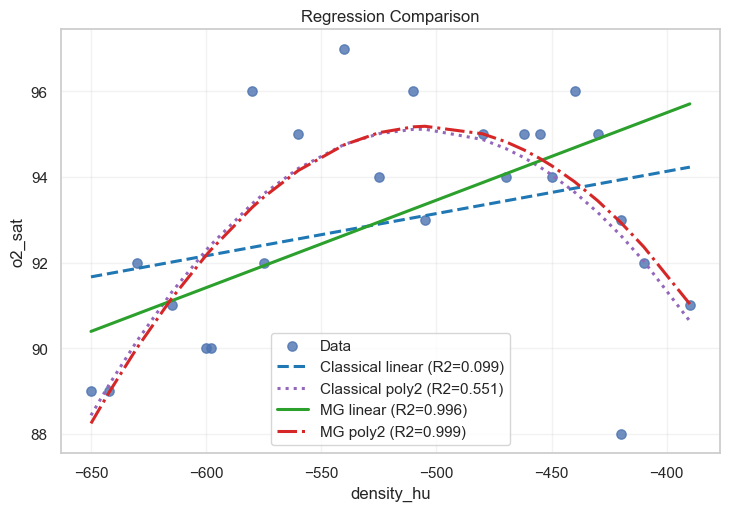

In [8]:
order = np.argsort(x)
x_sorted = x[order]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(x, y, s=45, alpha=0.8, label='Data')

ax.plot(x_sorted, cls['lin_pred'][order], linestyle='--', linewidth=2.2, color='tab:blue', label=f"Classical linear (R2={cls['lin_r2']:.3f})")
ax.plot(x_sorted, cls['poly_pred'][order], linestyle=':', linewidth=2.2, color='tab:purple', label=f"Classical poly2 (R2={cls['poly_r2']:.3f})")

if np.all(np.isfinite(mg['lin_pred'])):
    ax.plot(x_sorted, mg['lin_pred'][order], linestyle='-', linewidth=2.2, color='tab:green', label=f"MG linear (R2={mg['lin_r2']:.3f})")
if np.all(np.isfinite(mg['poly_pred'])):
    ax.plot(x_sorted, mg['poly_pred'][order], linestyle='-.', linewidth=2.2, color='tab:red', label=f"MG poly2 (R2={mg['poly_r2']:.3f})")

ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.set_title('Regression Comparison')
ax.legend(loc='best')
ax.grid(alpha=0.25)
plt.show()


## Step 7: Side-by-Side Comparison Table


In [9]:
comparison = pd.DataFrame(
    [
        ['mean(y)', cls['mean_y'], mg['mean_y']],
        ['median(y)', cls['median_y'], mg['median_y']],
        ['corr(x,y)', cls['corr_xy'], mg['corr_xy']],
        ['linear R2', cls['lin_r2'], mg['lin_r2']],
        ['linear RMSE', cls['lin_rmse'], mg['lin_rmse']],
        ['poly2 R2', cls['poly_r2'], mg['poly_r2']],
        ['poly2 RMSE', cls['poly_rmse'], mg['poly_rmse']],
        ['interval low', cls['ci_low'], mg['typical_low']],
        ['interval high', cls['ci_high'], mg['typical_high']],
    ],
    columns=['metric', 'classical', 'machine_gnostics']
)
comparison


,metric,classical,machine_gnostics
0,mean(y),93.000000,94.030000
1,median(y),93.500000,93.274000
2,"corr(x,y)",0.313931,0.985022
3,linear R2,0.098553,0.996075
4,linear RMSE,2.389386,1.421238
5,poly2 R2,0.551017,0.999080
6,poly2 RMSE,1.686285,0.987984
7,interval low,91.971490,91.875308
8,interval high,94.028510,95.788166


## Step 8: Dataset-Specific Classical Check
This step highlights the classical finding that can become misleading in small or confounded datasets.


In [11]:
print('Outcome-wise summary:')
print(df.groupby('outcome')['density_hu'].agg(['count','mean','min','max']))

z = (df['density_hu'] - df['density_hu'].mean()) / df['density_hu'].std(ddof=1)
print('Potential tail cases (|z| >= 1.5):')
print(df.loc[np.abs(z) >= 1.5, ['patient','density_hu','o2_sat','outcome']])


Outcome-wise summary:
            count        mean  min  max
outcome                                
Deceased        3 -617.333333 -642 -580
Discharged     16 -476.375000 -575 -390
ICU             5 -576.600000 -650 -420
Potential tail cases (|z| >= 1.5):
    patient  density_hu  o2_sat     outcome
4         5        -390      91  Discharged
11       12        -650      89         ICU
21       22        -642      89    Deceased


## Step 9: Key Takeaways

- Outcome: tail densities align better with severe outcomes than a single global mean radiodensity.
- Practical lesson: tail-risk and distribution shape can dominate average-based summaries in clinical data.
- Machine Gnostics value: interval and robust distribution analysis highlights high-risk structure hidden in means.
